In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pysindy as ps
import matplotlib

from config import PROCESSED_DIR, FIGURES_DIR, SEED

In [2]:
np.random.seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "figure.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.unicode_minus": False,
})

In [3]:
df = pd.read_parquet(PROCESSED_DIR / "SCS_CMIP6_MODIS_flat.parquet")

FEATURE_COLS = ["no3", "po4", "si", "dfe", "o2", "mlotst", "tos"]
TARGET_COL = "log_chla"

sub = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
train_df = sub[sub["split"] == "train"]
test_df = sub[sub["split"] == "test"]

X_train = train_df[FEATURE_COLS].values.astype(np.float64)
y_train = train_df[TARGET_COL].values.astype(np.float64)
X_test = test_df[FEATURE_COLS].values.astype(np.float64)
y_test = test_df[TARGET_COL].values.astype(np.float64)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Features: {FEATURE_COLS}")

Train: 40,515  Test: 12,987
Features: ['no3', 'po4', 'si', 'dfe', 'o2', 'mlotst', 'tos']


SINDy  degree=1  STLSQ (threshold=0.01)
Library features: 8
Theta shape: (40515, 8)
R2=0.5340  RMSE=0.2732  MAE=0.2009  Bias=-0.0076

Discovered formula (degree=1):
log_chla = 
    -0.7343 * 1
    -0.0227 * no3
    +0.0236 * po4
    -0.0520 * si
    +0.3333 * dfe
    -0.1176 * o2
    -0.2104 * tos


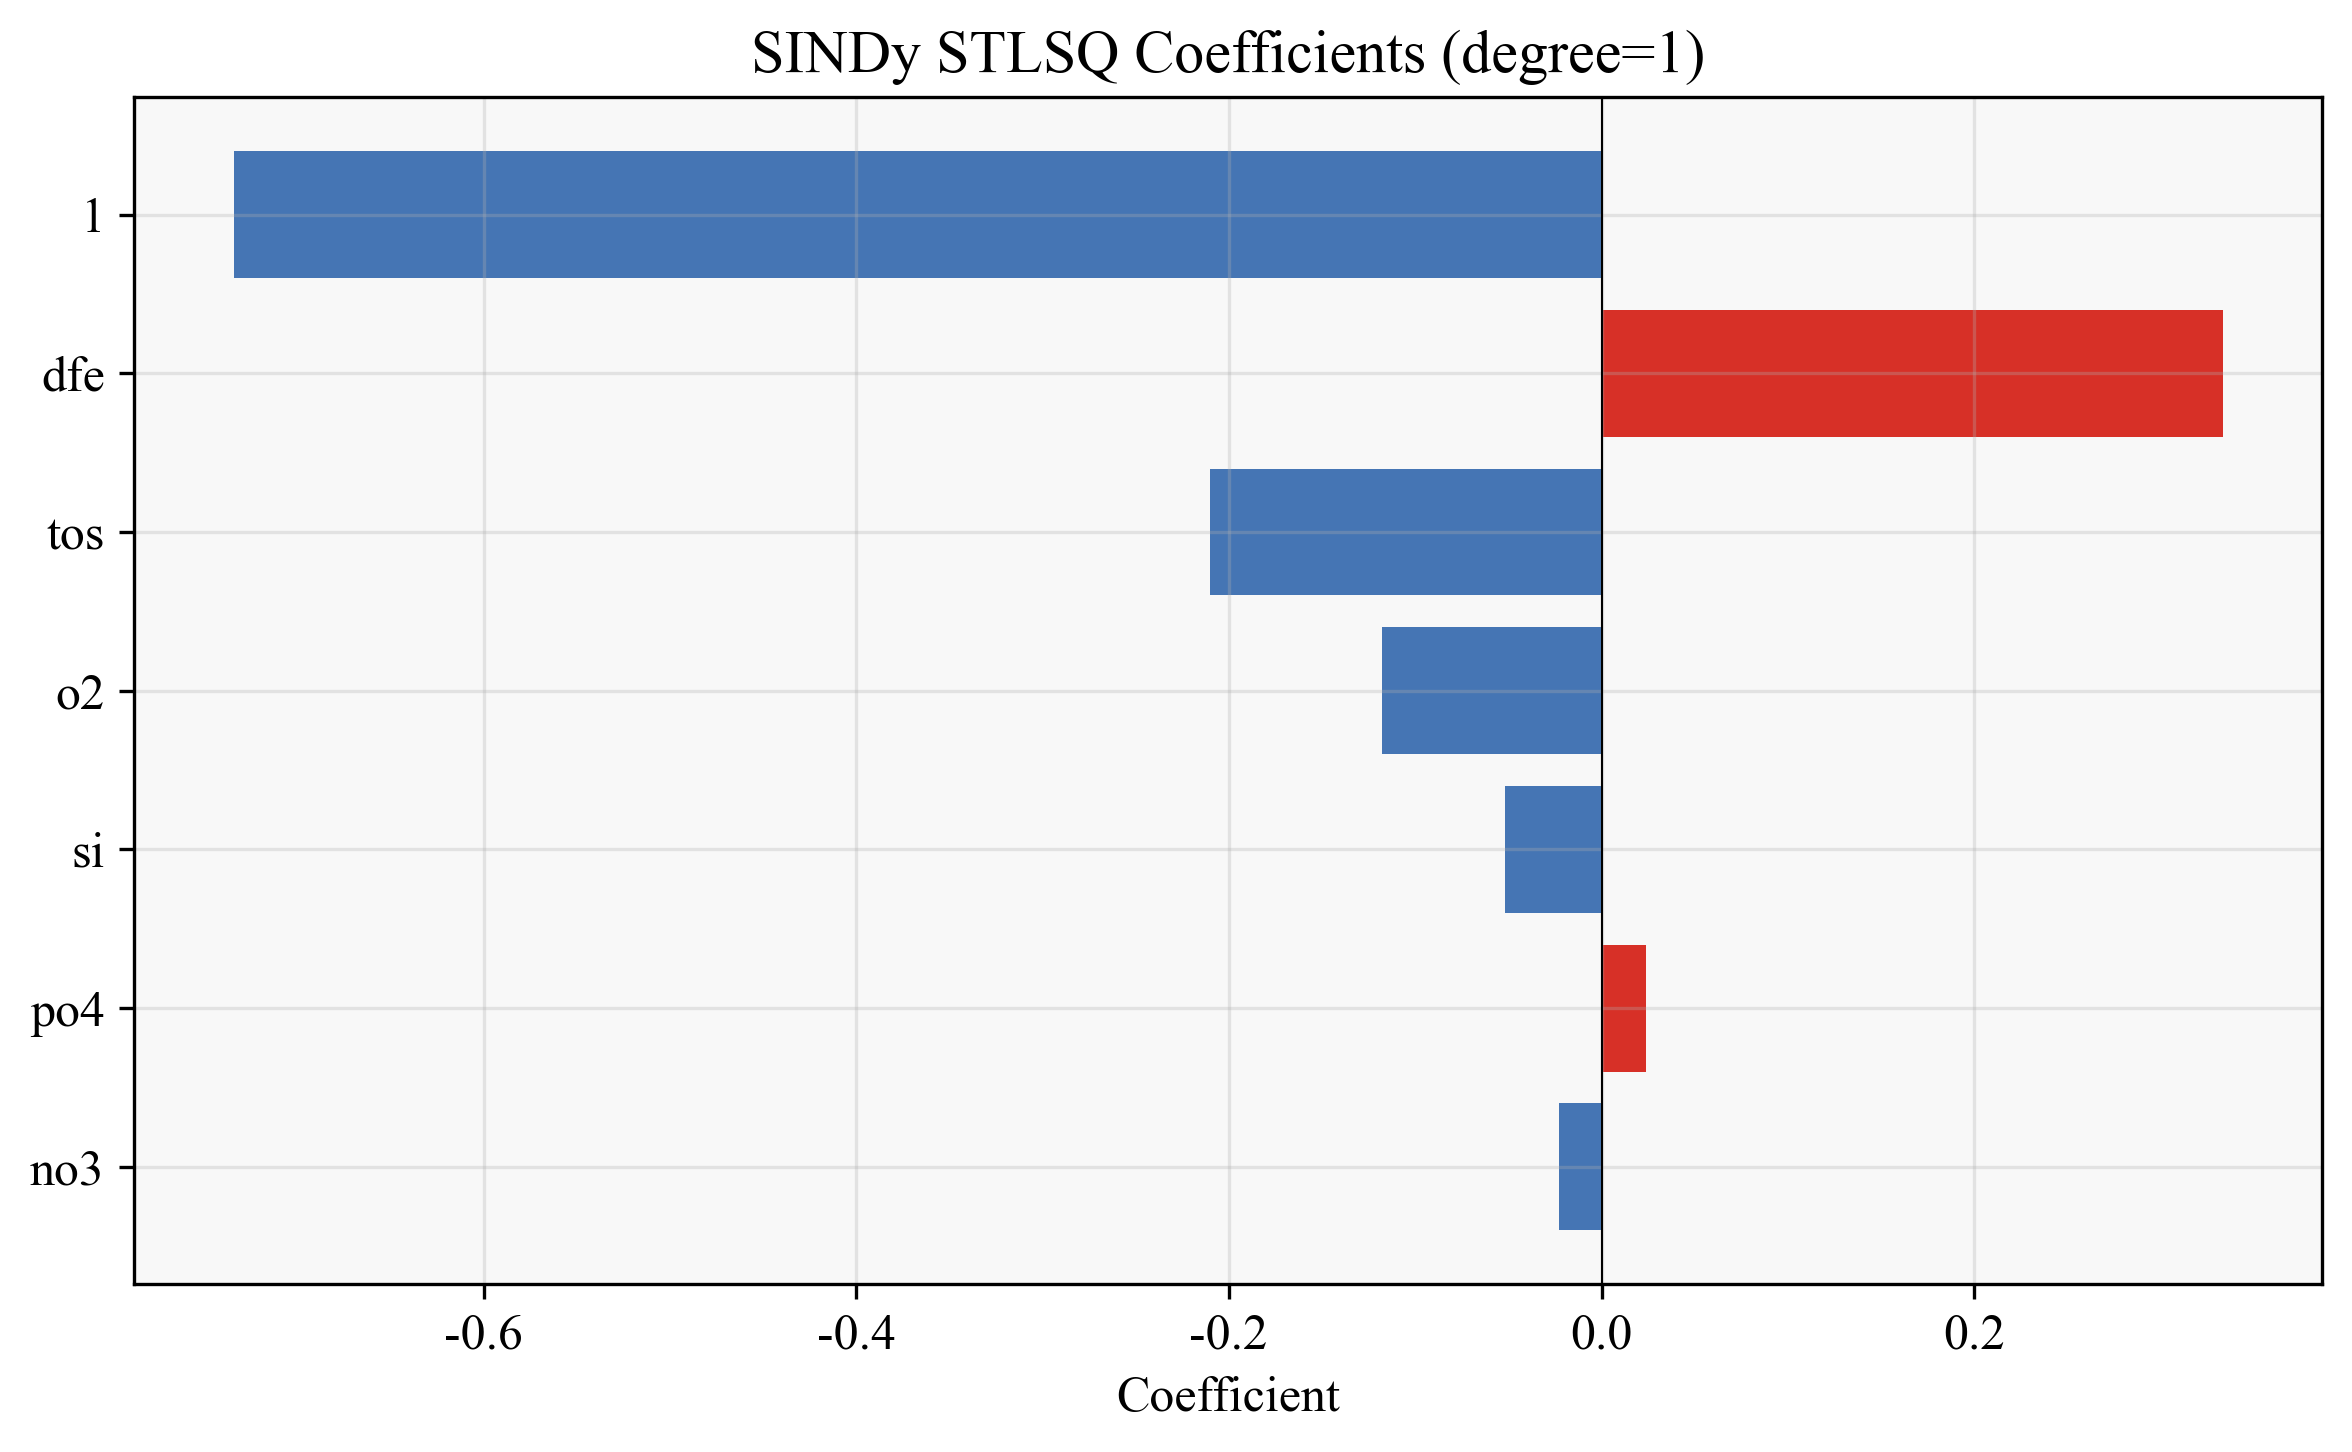

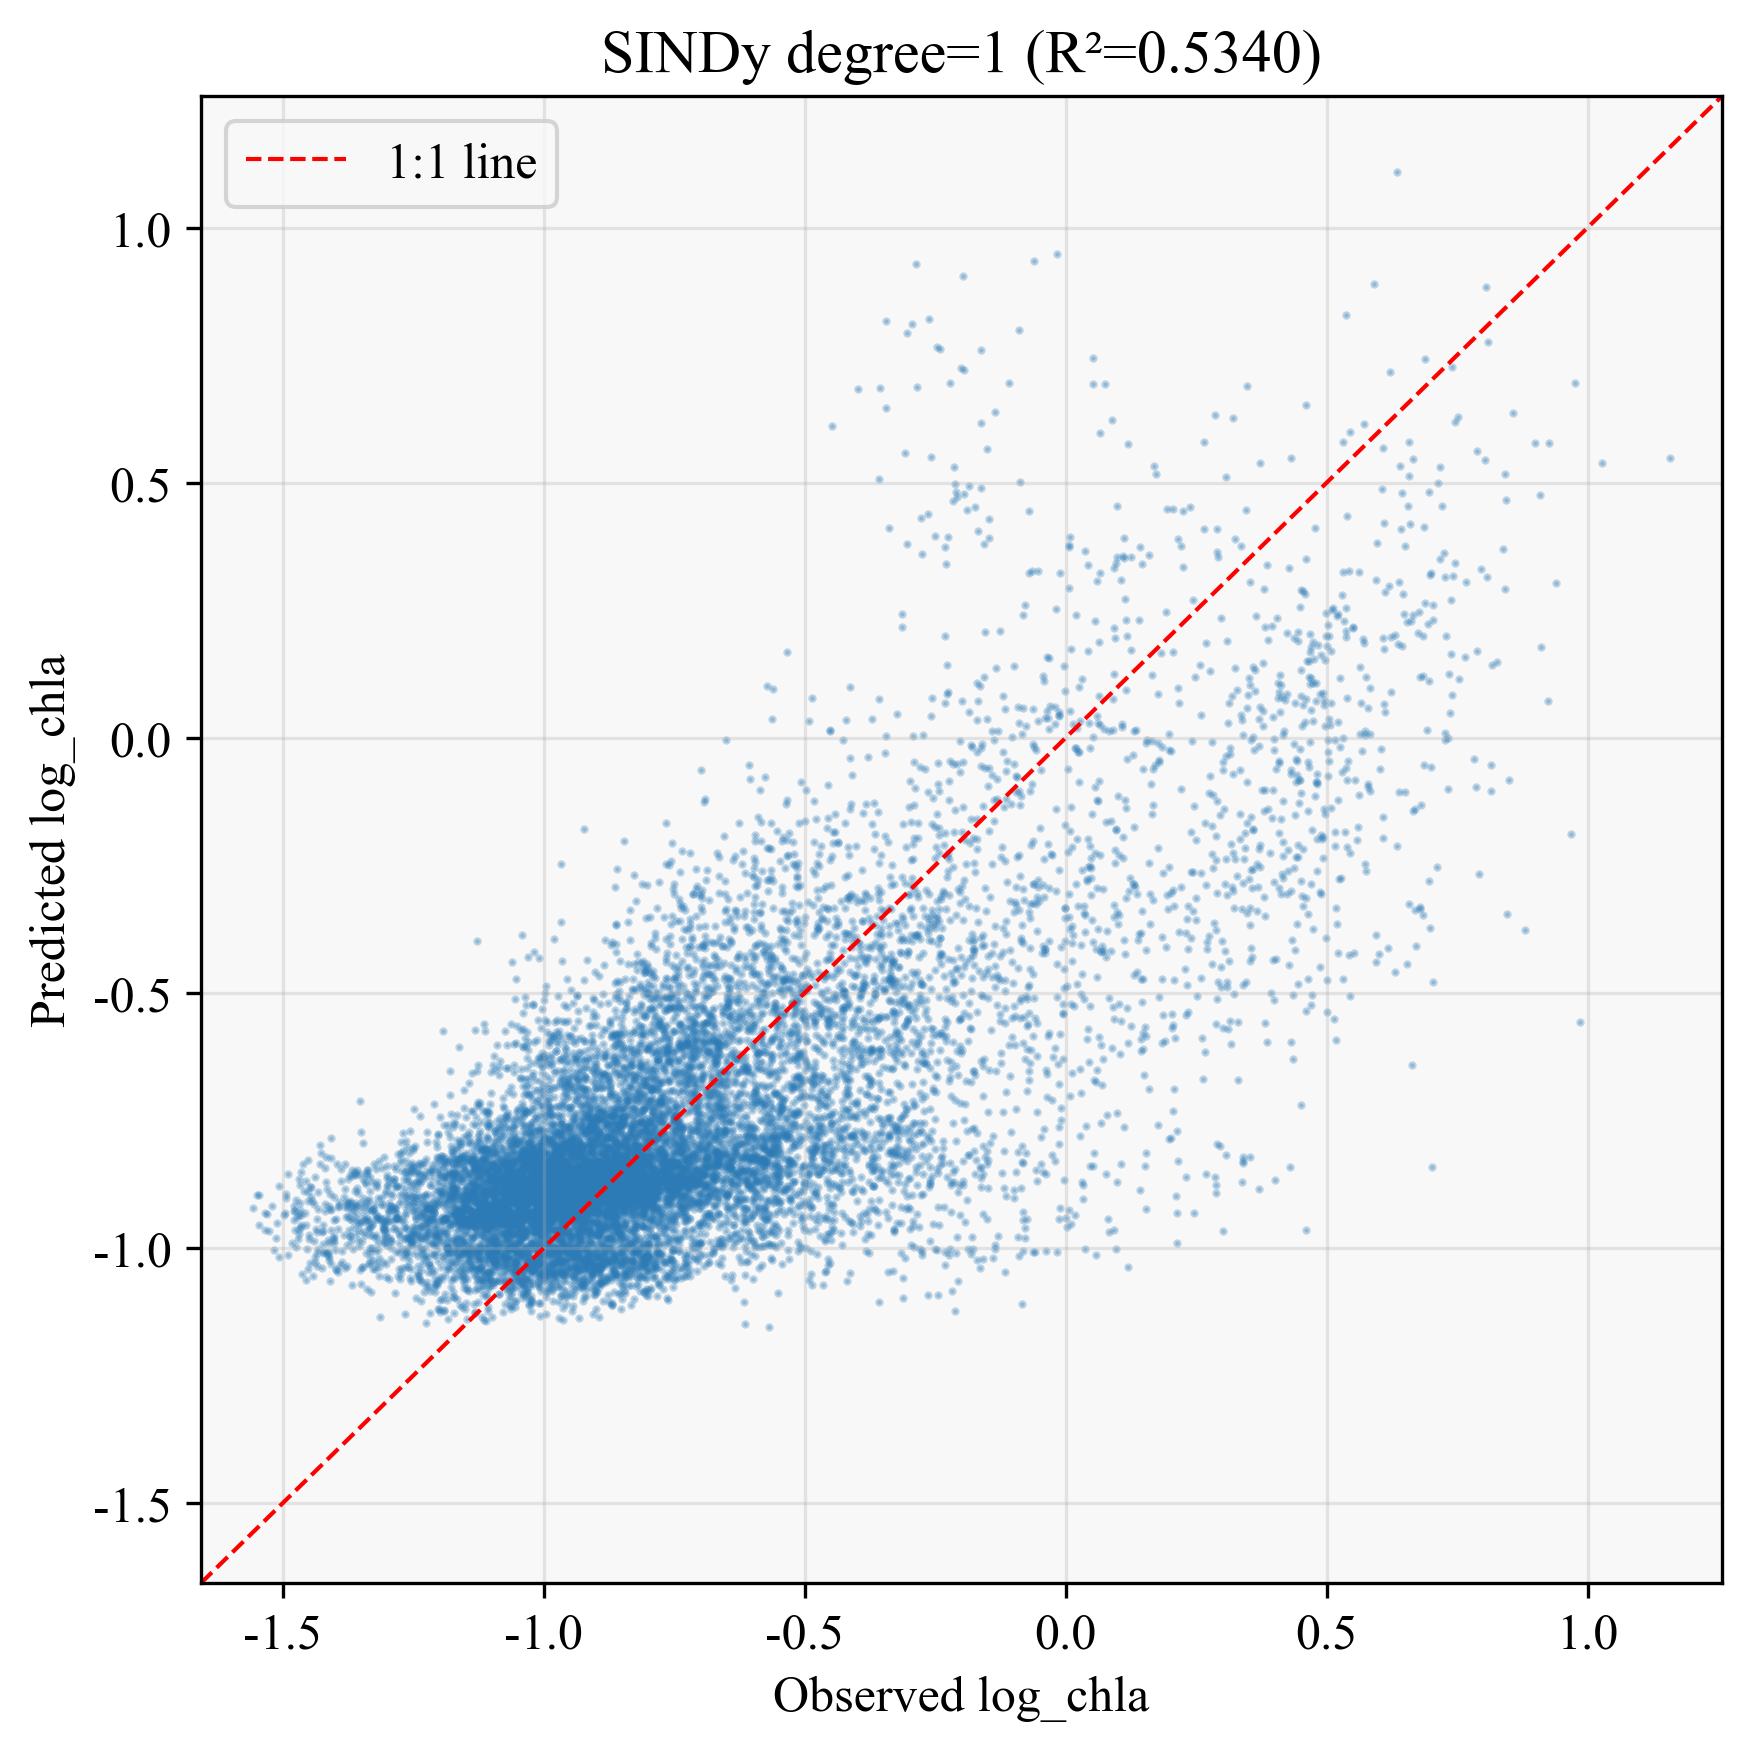

SINDy  degree=2  STLSQ (threshold=0.01)
Library features: 36
Theta shape: (40515, 36)
R2=0.5972  RMSE=0.2540  MAE=0.1847  Bias=-0.0075

Discovered formula (degree=2):
log_chla = 
    -0.6771 * 1
    -0.0574 * no3
    +0.1460 * po4
    -0.0802 * si
    +0.3934 * dfe
    -0.0892 * o2
    -0.1530 * tos
    -0.0118 * no3^2
    -0.0174 * no3 po4
    -0.0595 * no3 si
    +0.0655 * no3 dfe
    +0.0356 * no3 o2
    +0.0294 * no3 mlotst
    +0.0295 * no3 tos
    +0.0185 * po4 si
    -0.0262 * po4 dfe
    +0.0214 * po4 o2
    +0.0102 * po4 mlotst
    +0.0613 * po4 tos
    -0.0421 * si^2
    +0.0161 * si dfe
    +0.0147 * si o2
    -0.0651 * si tos
    -0.0425 * dfe^2
    -0.1448 * dfe o2
    -0.0362 * dfe mlotst
    -0.1064 * dfe tos
    +0.1360 * o2^2
    -0.0440 * o2 mlotst
    +0.3851 * o2 tos
    -0.0230 * mlotst tos
    +0.2834 * tos^2


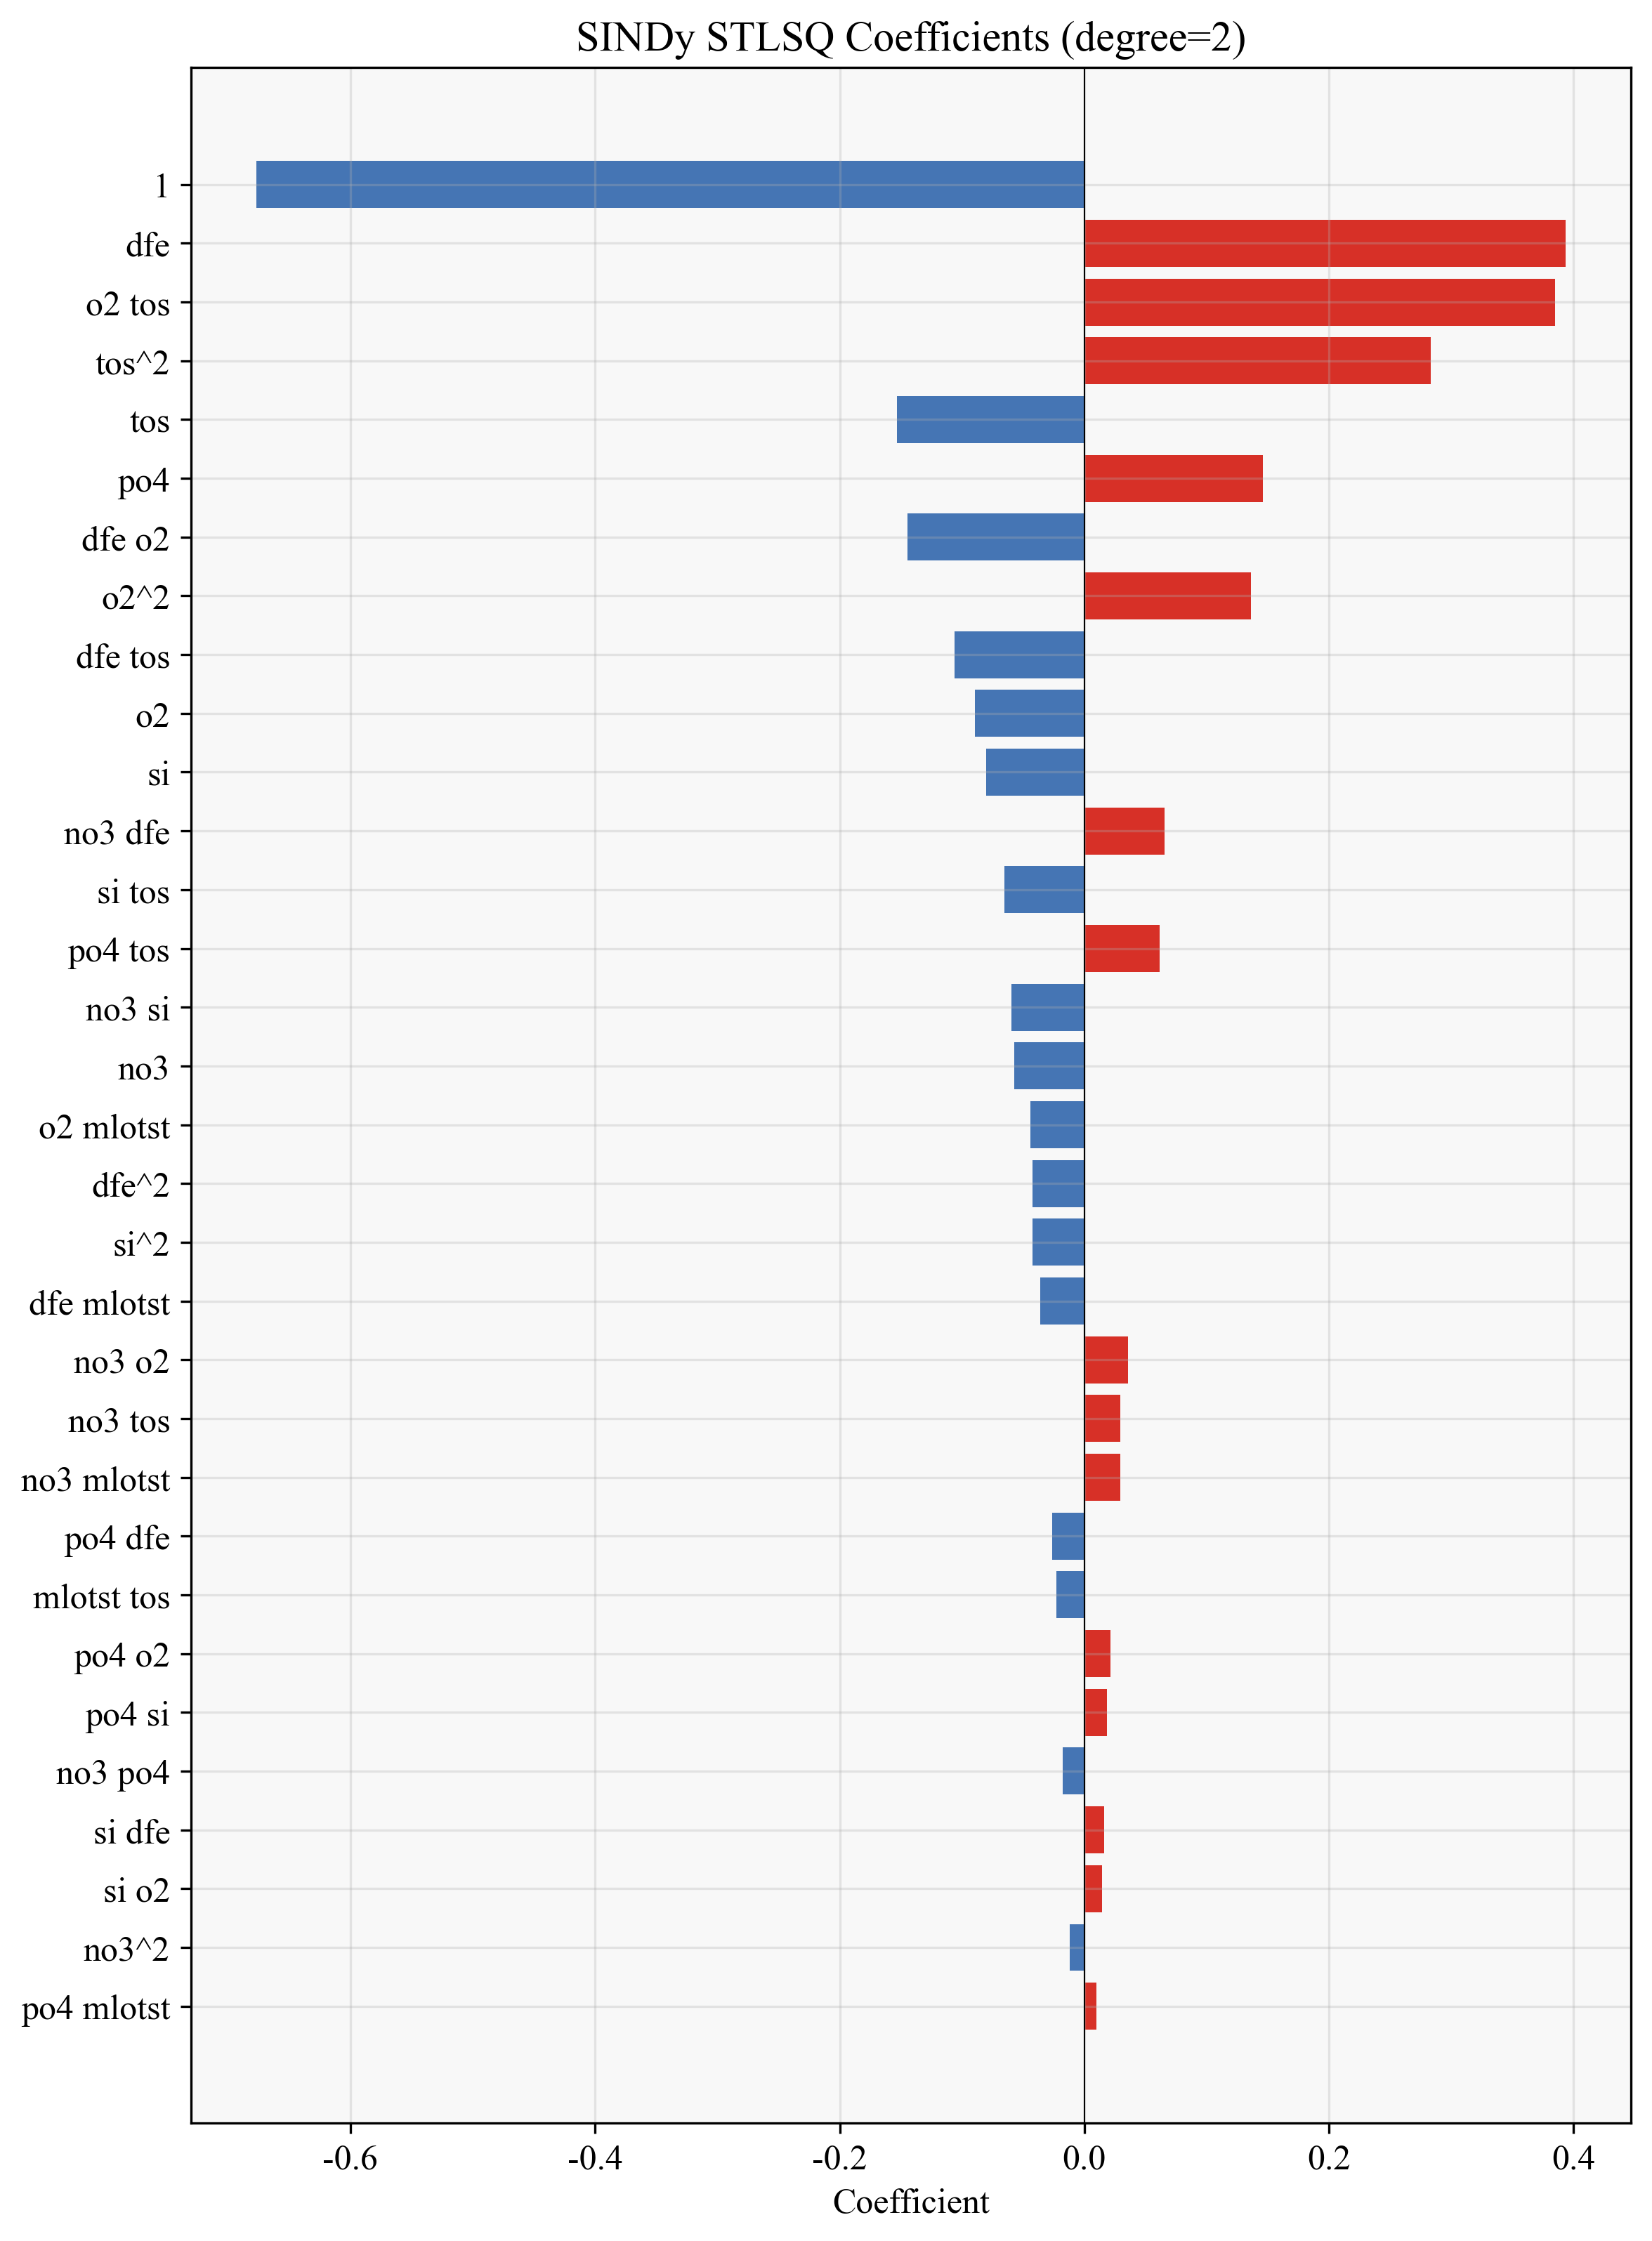

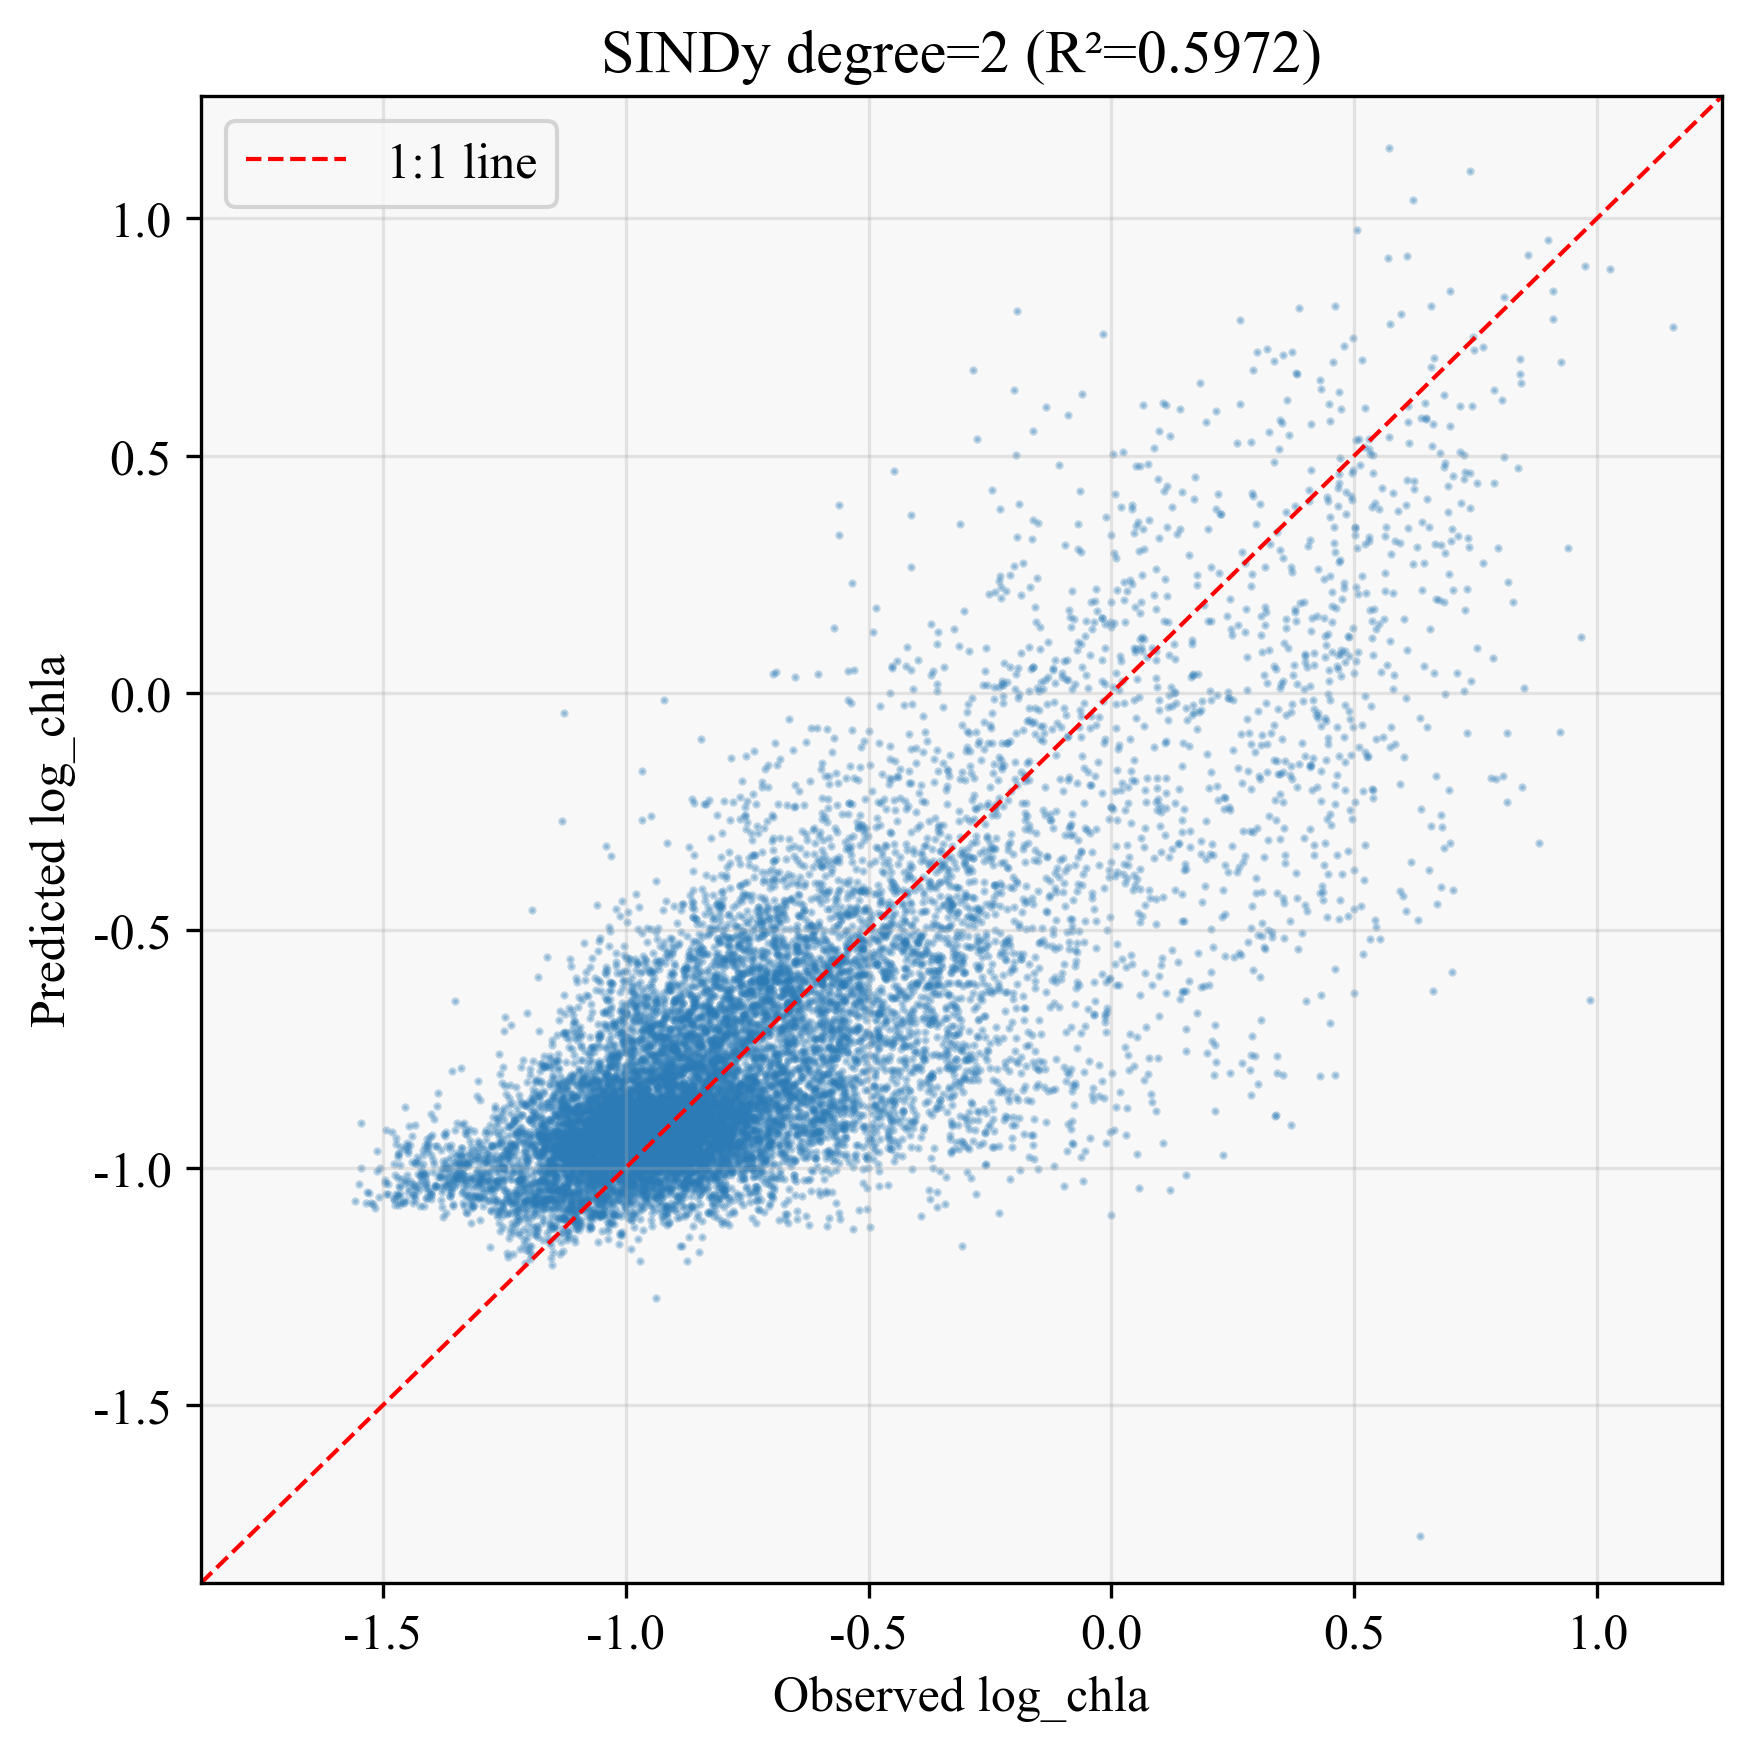

In [4]:
degrees = [1, 2]
all_metrics = {}
all_formulas = {}

for degree in degrees:
    tag = f"degree{degree}"
    print(f"SINDy  degree={degree}  STLSQ (threshold=0.01)")

    library = ps.PolynomialLibrary(degree=degree, include_interaction=True)
    library.fit(X_train_sc)

    Theta_train = library.transform(X_train_sc)
    Theta_test = library.transform(X_test_sc)
    feature_names = library.get_feature_names(input_features=FEATURE_COLS)

    print(f"Library features: {len(feature_names)}")
    print(f"Theta shape: {Theta_train.shape}")

    optimizer = ps.STLSQ(threshold=0.01, alpha=0.5, max_iter=100)
    optimizer.fit(Theta_train, y_train)
    coef = optimizer.coef_.flatten()

    y_pred = np.asarray(Theta_test) @ coef

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    bias = np.mean(y_pred - y_test)
    print(f"R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  Bias={bias:.4f}")

    all_metrics[tag] = {"degree": degree, "R2": r2, "RMSE": rmse, "MAE": mae, "Bias": bias}

    print(f"\nDiscovered formula (degree={degree}):")
    print(f"log_chla = ")
    formula_lines = []
    for name, c in zip(feature_names, coef):
        if abs(c) > 0.001:
            line = f"    {c:+.4f} * {name}"
            print(line)
            formula_lines.append({"feature": name, "coef": c})
    all_formulas[tag] = formula_lines

    fig, ax = plt.subplots(figsize=(8, max(5, len(feature_names) * 0.3)))
    mask = np.abs(coef) > 0.001
    names_sel = [feature_names[i] for i in range(len(coef)) if mask[i]]
    coef_sel = coef[mask]

    sorted_idx = np.argsort(np.abs(coef_sel))
    colors = ["#d73027" if c > 0 else "#4575b4" for c in coef_sel[sorted_idx]]
    ax.barh(
        [names_sel[i] for i in sorted_idx],
        coef_sel[sorted_idx],
        color=colors
    )
    ax.set_xlabel("Coefficient")
    ax.set_title(f"SINDy STLSQ Coefficients (degree={degree})")
    ax.axvline(0, color="black", lw=0.5)
    fig.tight_layout()
    plt.show()
    p = FIGURES_DIR / f"fig_sindy_coefficients_{tag}.png"
    fig.savefig(p, dpi=300, bbox_inches="tight")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test, y_pred, s=1, alpha=0.3, c="#2c7bb6")
    lims = [min(y_test.min(), y_pred.min()) - 0.1,
            max(y_test.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, "r--", lw=1, label="1:1 line")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Observed log_chla")
    ax.set_ylabel("Predicted log_chla")
    ax.set_title(f"SINDy degree={degree} (R²={r2:.4f})")
    ax.legend()
    fig.tight_layout()
    plt.show()
    p = FIGURES_DIR / f"fig_sindy_scatter_{tag}.png"
    fig.savefig(p, dpi=300, bbox_inches="tight")